# Regression with pyCaret Notebook

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
from pycaret.regression import *
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load a sample dataset
# For demonstration, we'll use the 'tips' dataset from seaborn
data = sns.load_dataset('tips')

In [3]:
data.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [4]:
# Split the data into training and test sets
from sklearn.model_selection import train_test_split
train, test = train_test_split(data, test_size=0.2, random_state=42)

In [5]:
# Initialize the PyCaret regression setup without experiment logging
regression_setup = setup(
    data=train,
    target='tip',
    session_id=123,
    normalize=True,
    polynomial_features=True,
    remove_multicollinearity=True,
    log_experiment=False,  # Disable experiment logging
    experiment_name='tips_regression',
    verbose=False  # Suppress logs
)

In [6]:
models()

,Name,Reference,Turbo
ID,,,
lr,Linear Regression,sklearn.linear_model._base.LinearRegression,True
lasso,Lasso Regression,sklearn.linear_model._coordinate_descent.Lasso,True
ridge,Ridge Regression,sklearn.linear_model._ridge.Ridge,True
en,Elastic Net,sklearn.linear_model._coordinate_descent.Elast...,True
lar,Least Angle Regression,sklearn.linear_model._least_angle.Lars,True
llar,Lasso Least Angle Regression,sklearn.linear_model._least_angle.LassoLars,True
omp,Orthogonal Matching Pursuit,sklearn.linear_model._omp.OrthogonalMatchingPu...,True
br,Bayesian Ridge,sklearn.linear_model._bayes.BayesianRidge,True
ard,Automatic Relevance Determination,sklearn.linear_model._bayes.ARDRegression,False


In [7]:
# Compare models to find the best one
best_model = compare_models()

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
ridge,Ridge Regression,0.7701,1.0373,0.9973,0.3885,0.2400,0.2896,0.1100
huber,Huber Regressor,0.7572,1.0332,0.9907,0.3812,0.2396,0.2840,0.1090
lr,Linear Regression,0.7700,1.0642,1.0102,0.3691,0.2444,0.2896,1.5750
br,Bayesian Ridge,0.8066,1.1166,1.0384,0.3621,0.2478,0.3062,0.0900
omp,Orthogonal Matching Pursuit,0.8308,1.1617,1.0522,0.3525,0.2519,0.3118,0.0920
lightgbm,Light Gradient Boosting Machine,0.8120,1.1819,1.0611,0.3382,0.2534,0.3098,0.1890
ada,AdaBoost Regressor,0.8504,1.2581,1.0904,0.2829,0.2563,0.3188,0.1700
knn,K Neighbors Regressor,0.8371,1.2742,1.1138,0.2640,0.2634,0.3126,0.0920
rf,Random Forest Regressor,0.8709,1.3176,1.1085,0.2587,0.2589,0.3255,0.1920
et,Extra Trees Regressor,0.8943,1.3439,1.1266,0.2393,0.2682,0.3305,0.2030


## Comparison will test 18 Regression models


In [8]:
# Print the best model
print(best_model)

Ridge(random_state=123)


In [9]:
# Tune the best model for better performance
tuned_model = tune_model(best_model, 
                         optimize='MAE',  # Optimize for Mean Absolute Error
                         )

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.9285,1.2943,1.1377,0.0748,0.2937,0.3909
1,1.0246,1.5742,1.2547,0.3647,0.2471,0.2743
2,0.8414,0.9788,0.9893,0.2828,0.2909,0.4245
3,0.8326,1.7076,1.3068,-0.1388,0.2933,0.2713
4,0.8196,1.3089,1.1441,0.0665,0.3065,0.3995
5,0.6010,0.5600,0.7483,0.7420,0.1697,0.2052
6,0.7864,1.0785,1.0385,0.3606,0.2287,0.2370
7,0.5271,0.4653,0.6821,0.6701,0.1968,0.2601
8,0.7521,0.9209,0.9596,0.7263,0.2103,0.2056


Fitting 10 folds for each of 10 candidates, totalling 100 fits


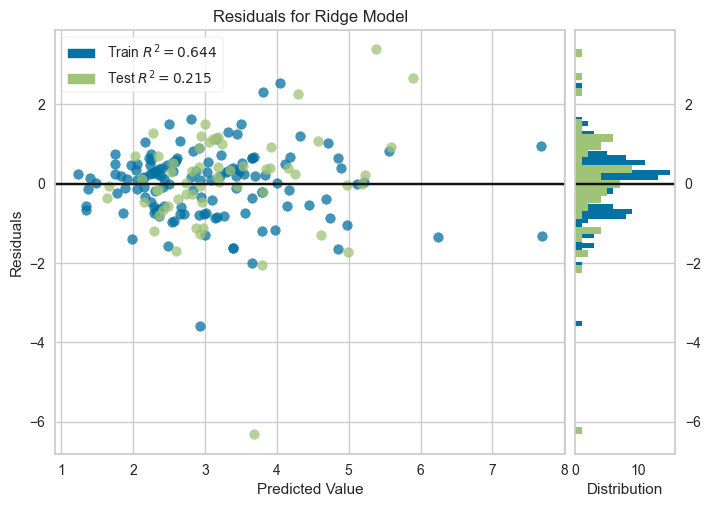

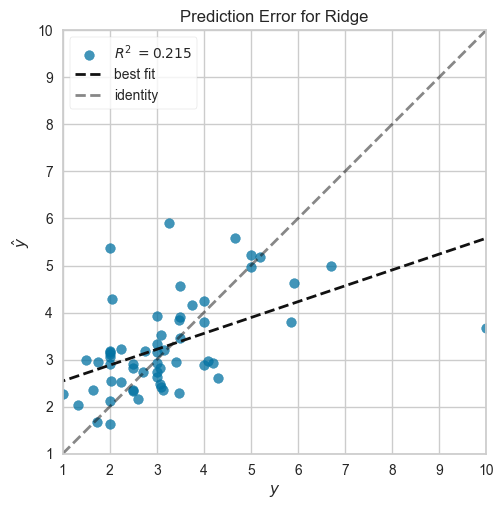

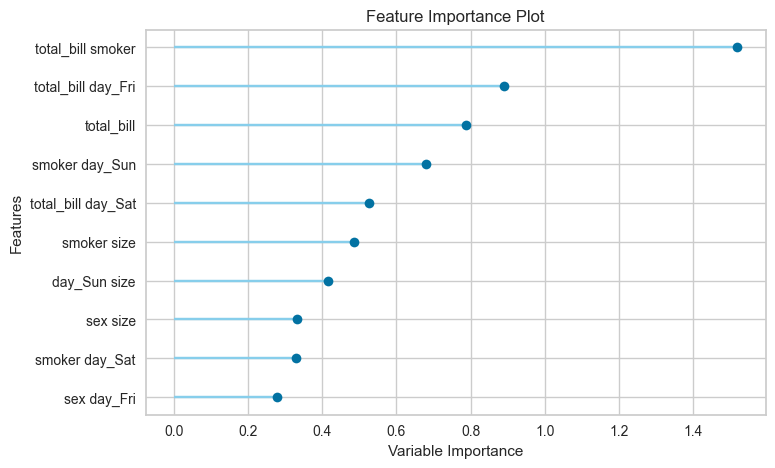

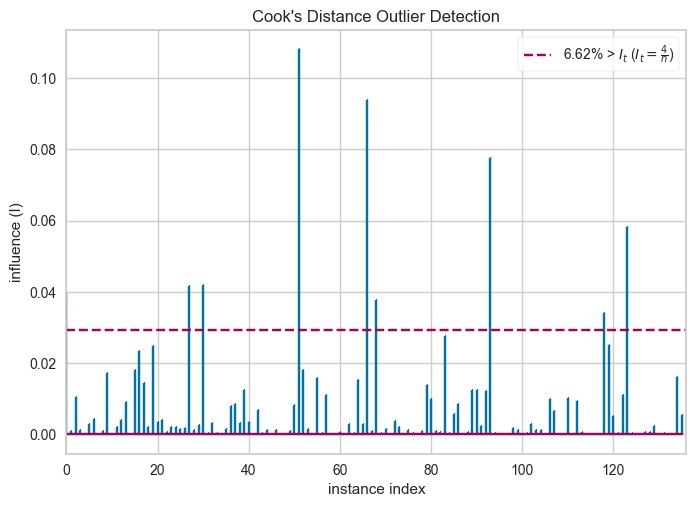

In [10]:
# Evaluate the tuned model
plot_model(tuned_model, plot='residuals')
plot_model(tuned_model, plot='error')
plot_model(tuned_model, plot='feature')
plot_model(tuned_model, plot='cooks')

### Cooks Distance:
- Cook's distance is a measure that combines the influence of leverage and residual size. It is used to identify influential data points in a regression analysis. The Cook's distance is a measure of the influence of each individual observation on the regression coefficients. It is used to identify influential data points in a regression analysis. The Cook's distance is a measure of the influence of each individual observation on the regression coefficients.

In [11]:
# evaluate model for better understanding using pycaret
evaluate_model(tuned_model)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

In [12]:
# Finalize the model for deployment
final_model = finalize_model(tuned_model)

In [13]:
# Predict on the test dataset
predictions = predict_model(final_model, data=test)

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Ridge Regression,0.7919,0.9843,0.9921,0.2126,0.2373,0.3166


In [14]:
# Evaluate performance
from sklearn.metrics import mean_squared_error, r2_score

In [15]:
# Extract true and predicted values
true_values = test['tip']
# Verify the actual column name in predictions
print(predictions.columns)

# Replace 'Label' with the correct column name based on the output above
predicted_values = predictions['prediction_label']  # Update 'Label' if the column name is different

Index(['total_bill', 'sex', 'smoker', 'day', 'time', 'size', 'tip',
       'prediction_label'],
      dtype='object')


In [16]:
# Calculate metrics
mse = mean_squared_error(true_values, predicted_values)
r2 = r2_score(true_values, predicted_values)

print(f"Mean Squared Error: {mse}")
print(f"R-squared: {r2}")

Mean Squared Error: 0.9842719711333283
R-squared: 0.212564372090855


In [17]:
# Save the model for later use
save_model(final_model, './saved_models/pycaret_best_tips_regression_model')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(include=['total_bill', 'size'],
                                     transformer=SimpleImputer())),
                 ('categorical_imputer',
                  TransformerWrapper(include=['sex', 'smoker', 'day', 'time'],
                                     transformer=SimpleImputer(strategy='most_frequent'))),
                 ('ordinal_encoding',
                  TransformerWrapper(include=['sex', 'smoker', 'time'],...
                                                               handle_missing='return_nan',
                                                               use_cat_names=True))),
                 ('polynomial_features',
                  TransformerWrapper(transformer=PolynomialFeatures(include_bias=False))),
                 ('remove_multicollinearity',
                  TransformerWrapper(exclude=[],
                                     transformer=Remov

In [18]:
# Load the saved model (optional)
loaded_model = load_model('./saved_models/pycaret_best_tips_regression_model')

Transformation Pipeline and Model Successfully Loaded


In [19]:
# Make predictions with the loaded model (optional)
new_predictions = predict_model(loaded_model, data=test)

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Ridge Regression,0.7919,0.9843,0.9921,0.2126,0.2373,0.3166


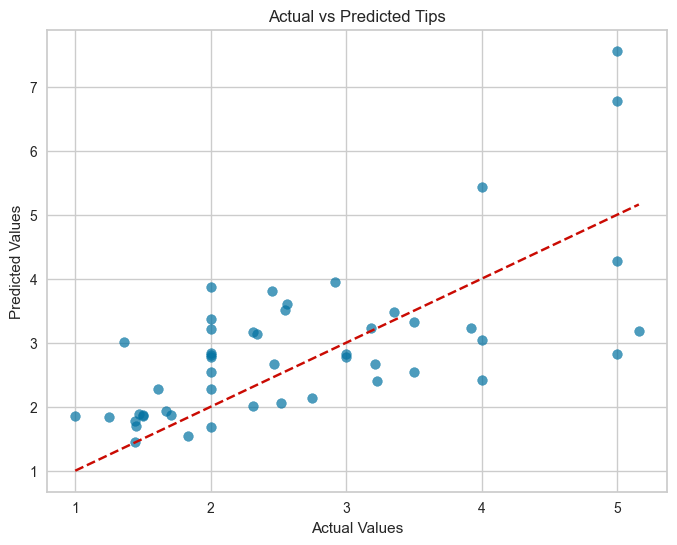

In [20]:
# Additional Analysis
# Plot actual vs predicted values
plt.figure(figsize=(8, 6))
plt.scatter(true_values, predicted_values, alpha=0.7)
plt.plot([true_values.min(), true_values.max()], [true_values.min(), true_values.max()], '--r')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs Predicted Tips')
plt.show()

# About the Author

<div style="background-color: #f8f9fa; border-left: 5px solid #28a745; padding: 20px; margin-bottom: 20px; border-radius: 5px;">
  <h2 style="color: #28a745; margin-top: 0; font-family: 'Poppins', sans-serif;">Muhammad Atif Latif</h2>
  <p style="font-size: 16px; color: #495057;">Data Scientist & Machine Learning Engineer</p>
  
  <p style="font-size: 15px; color: #6c757d; margin-top: 15px;">
    Passionate about building AI solutions that solve real-world problems. Specialized in machine learning, 
    deep learning, and data analytics with experience implementing production-ready models.
  </p>
</div>

## Connect With Me

<div style="display: flex; flex-wrap: wrap; gap: 10px; margin-top: 15px;">
  <a href="https://github.com/m-Atif-Latif" target="_blank">
    <img src="https://img.shields.io/badge/GitHub-Follow-212121?style=for-the-badge&logo=github" alt="GitHub">
  </a>
  <a href="https://www.kaggle.com/matiflatif" target="_blank">
    <img src="https://img.shields.io/badge/Kaggle-Profile-20BEFF?style=for-the-badge&logo=kaggle" alt="Kaggle">
  </a>
  <a href="https://www.linkedin.com/in/muhammad-atif-latif-13a171318" target="_blank">
    <img src="https://img.shields.io/badge/LinkedIn-Connect-0077B5?style=for-the-badge&logo=linkedin" alt="LinkedIn">
  </a>
  <a href="https://x.com/mianatif5867" target="_blank">
    <img src="https://img.shields.io/badge/Twitter-Follow-1DA1F2?style=for-the-badge&logo=twitter" alt="Twitter">
  </a>
  <a href="https://www.instagram.com/its_atif_ai/" target="_blank">
    <img src="https://img.shields.io/badge/Instagram-Follow-E4405F?style=for-the-badge&logo=instagram" alt="Instagram">
  </a>
  <a href="mailto:muhammadatiflatif67@gmail.com">
    <img src="https://img.shields.io/badge/Email-Contact-D14836?style=for-the-badge&logo=gmail" alt="Email">
  </a>
</div>

---